# **Homeniq Machine Learning for California Housing Price Prediction**
***

## **Business Introduction**

### 1. Company Context
Homeniq is an independent property valuation firm based in California, providing objective and data-driven market value estimates for residential and commercial properties. Unlike real estate agencies, Homeniq does not represent buyers or sellers. Our valuations are designed to be objective, consistent, and data-driven, supporting lenders, appraisers, insurers, and property owners.

### 2. Problem Statement
California's real estate market is highly dynamic, with property values influenced by factors such as location, income levels, and housing characteristics. Traditional appraisal processes rely heavily on manual analysis and professional judgment, making them time-consuming and potentially inconsistent. Homeniq aims to develop a machine learning valuation model that can generate fast and consistent property value estimates as a decision-support tool for certified appraisers.

### 3. Project Goals
Develop a machine learning model capable of accurately estimating property market value based on key influencing factors. Accelerate the pre-screening process for mortgage applications and appraisal requests, reducing full dependency on manual valuation. Provide a consistent, defensible estimate that supports lenders, appraisers, and insurers in making faster and more informed decisions. Improve valuation transparency by identifying which property and location factors most strongly influence estimated value.

> **Note:** Model predictions support the appraisal process and do not replace certified appraisers.

### 4. Stakeholders

* Management: Business strategy and pricing decisions.
* Data & Analytics Team: Model development and validation.
* Advisory Team: Uses model outputs for client recommendations.
* Property Owners: Receive data-driven pricing insights.
* Buyers: Gain a more objective reference for property prices.
* Appraisers & Financial Institutions: Use estimates as additional decision support.

### 5. Analytical Approach

1. Data Exploration, analyze the dataset to understand:
* Property value distribution
* Relationships between features and price
* Location and housing patterns
* Outliers and data quality issues

2. Data Preprocessing
* Handle missing values using appropriate imputation methods.
* Convert categorical variables using One-Hot Encoding.
* Scale numerical features where required.
* Check for outliers and inconsistent data.

3. Model Development, several regression models are compared:
* Linear Regression: Baseline model
* Decision Tree Regression: Captures non-linear relationships
* Random Forest Regression: Captures complex patterns and feature interactions

4. Model Evaluation, models are trained on the training dataset and evaluated on unseen test data using:
* RMSE (Root Mean Squared Error): Measures prediction error and penalizes large errors.
* MAE (Mean Absolute Error): Measures the average prediction error.
* MAPE (Mean Absolute Percentage Error): Measures prediction error as a percentage.
* R² (R-squared) / Adjusted R²: Evaluates explanatory power, particularly for linear models.

Lower RMSE, MAE, and MAPE indicate better performance, while higher R² indicates stronger explanatory power.

### 6. Expected Business Impact

The model is expected to help Homeniq:
* Accelerate preliminary property valuation
* Improve consistency across valuations
* Support faster data-driven decisions
* Identify key property value drivers
* Scale valuation analysis more efficiently

The final solution combines machine learning predictions with professional appraisal expertise to deliver faster and more consistent valuation support.


## **Data Understanding**

- This dataset contains information about housing prices in California based on various features that influence house prices.
- The dataset consists of 14,448 rows and 10 columns. Nine columns are numerical, while one column is categorical.
- Each row represents information about a registered residential property, including demographic, geographic, and economic attributes of the area where the property is located.

| Attribute | Data Type | Description |
|---|---|---|
| **longitude** | Float | The longitude coordinate of the property's location. |
| **latitude** | Float | The latitude coordinate of the property's location. |
| **housing_median_age** | Float | The median age of houses in the area. |
| **total_rooms** | Integer | The total number of rooms in the house or property. |
| **total_bedrooms** | Integer | The total number of bedrooms in the house. |
| **population** | Integer | The number of people living around the property's location. |
| **households** | Integer | The total number of households in the area. |
| **median_income** | Float | The median income per capita in the area. |
| **ocean_proximity** | Object | The category representing the property's proximity to the ocean, such as `INLAND`, `NEAR BAY`, or `<1H OCEAN`. |
| **median_house_value** | Integer | The median house value in US dollars for properties in the area. |

## **Import Library & Load Dataset**

In [170]:
# IMPORT LIBRARY
import pandas as pd  
import numpy as np  
import seaborn as sns  
import geopandas as gpd
import matplotlib.pyplot as plt  
import warnings
warnings.filterwarnings('ignore')

# Split data 
from sklearn.model_selection import train_test_split  

# Column transformer
from sklearn.compose import ColumnTransformer  
from sklearn.pipeline import Pipeline  

# Imputer
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer  

# Encoding
from sklearn.preprocessing import OneHotEncoder  
import category_encoders as ce  

# Scaling
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler  

# Polynomial
from sklearn.preprocessing import PolynomialFeatures  

# Cross-validation
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score, cross_validate  

# Modeling
from sklearn.tree import DecisionTreeRegressor, plot_tree  
from sklearn.neighbors import KNeighborsRegressor  
from sklearn.linear_model import LinearRegression, Ridge, Lasso  
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor  # type: ignore
from sklearn.compose import TransformedTargetRegressor
import statsmodels.api as sm  

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV  

# Scoring
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

# Save Model
import pickle

In [161]:
# LOAD DATASET
df = pd.read_csv('data_california_house.csv')
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-119.79,36.73,52.0,112.0,28.0,193.0,40.0,1.9750,INLAND,47500.0
1,-122.21,37.77,43.0,1017.0,328.0,836.0,277.0,2.2604,NEAR BAY,100000.0
2,-118.04,33.87,17.0,2358.0,396.0,1387.0,364.0,6.2990,<1H OCEAN,285800.0
3,-118.28,34.06,17.0,2518.0,1196.0,3051.0,1000.0,1.7199,<1H OCEAN,175000.0
4,-119.81,36.73,50.0,772.0,194.0,606.0,167.0,2.2206,INLAND,59200.0
...,...,...,...,...,...,...,...,...,...,...
14443,-121.26,38.27,20.0,1314.0,229.0,712.0,219.0,4.4125,INLAND,144600.0
14444,-120.89,37.48,27.0,1118.0,195.0,647.0,209.0,2.9135,INLAND,159400.0
14445,-121.90,36.58,31.0,1431.0,NaN,704.0,393.0,3.1977,NEAR OCEAN,289300.0
14446,-117.93,33.62,34.0,2125.0,498.0,1052.0,468.0,5.6315,<1H OCEAN,484600.0


## **Exploratory Data Analysis (EDA)**

### **1. Data Information**

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14448 entries, 0 to 14447
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           14448 non-null  float64
 1   latitude            14448 non-null  float64
 2   housing_median_age  14448 non-null  float64
 3   total_rooms         14448 non-null  float64
 4   total_bedrooms      14311 non-null  float64
 5   population          14448 non-null  float64
 6   households          14448 non-null  float64
 7   median_income       14448 non-null  float64
 8   ocean_proximity     14448 non-null  object 
 9   median_house_value  14448 non-null  float64
dtypes: float64(9), object(1)
memory usage: 1.1+ MB


The dataset contains 14,448 records and 10 features, consisting of 9 numerical variables and 1 categorical variable. In addition, the total_bedrooms column contains missing values, as its number of non-null records is lower than the total 14,448 observations.


### 2. **Target Variable Distribution: median_house_value**

<Axes: xlabel='median_house_value', ylabel='Count'>

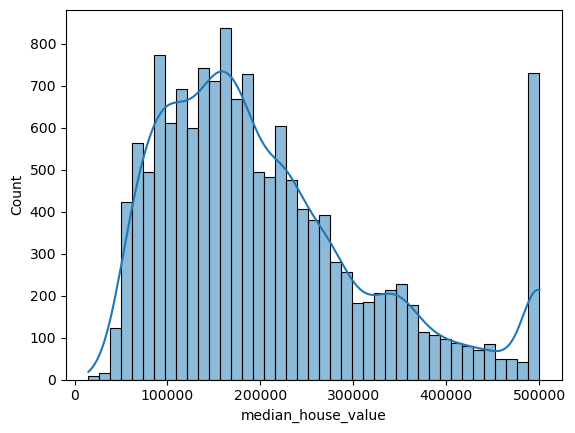

In [25]:
sns.histplot(data=df, x='median_house_value', kde=True)

**Interpretation:**

* Based on the distribution plot of **median house value**, the target variable shows a **right-skewed distribution**, indicating positive skewness.
* Most house prices are concentrated in the **low-to-middle price range**, while a smaller proportion of properties have higher values, creating a long right tail.
* The noticeable spike at approximately **$500,000** suggests a potential **upper price cap in the dataset**, which may affect the performance and predictions of the regression models.


### 3. **Numerical Feature Distribution**

In [26]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,14448.000000,14448.000000,14448.000000,14448.000000,14311.000000,14448.000000,14448.000000,14448.000000,14448.000000
mean,-119.566647,35.630093,28.618702,2640.132683,538.260709,1425.157323,499.508929,3.866667,206824.624516
std,2.006587,2.140121,12.596694,2191.612441,423.577544,1149.580157,383.098390,1.891158,115365.476182
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1451.000000,295.000000,784.000000,279.000000,2.570600,119600.000000
50%,-118.490000,34.260000,29.000000,2125.000000,435.000000,1165.000000,410.000000,3.539100,180000.000000
75%,-118.000000,37.710000,37.000000,3148.000000,647.000000,1724.000000,604.000000,4.736100,263900.000000
max,-114.310000,41.950000,52.000000,32627.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


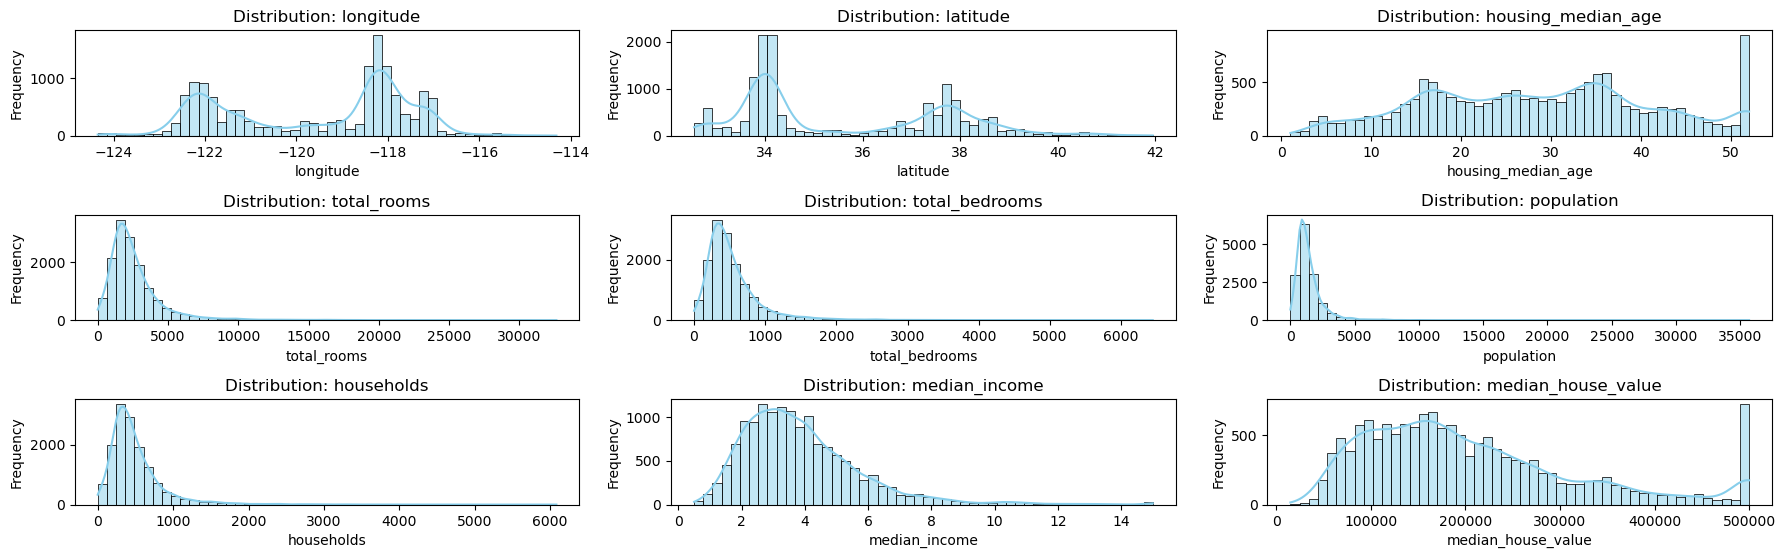

In [41]:
numerical_cols = df.describe().columns

plt.figure(figsize=(18, 20))

for i, column in enumerate(numerical_cols):
    plt.subplot(11, 3, i + 1)
    sns.histplot(df[column], kde=True, bins=50, color='skyblue')
    plt.title(f'Distribution: {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Interpretation:

* Longitude and latitude should not be removed, as they represent geographic location. Although they are location-related features, their data type needs to remain numerical to preserve their function as geographic coordinates.
* housing_median_age and median_house_value show noticeable distribution irregularities, with a large concentration of observations at certain values.
* Most numerical features are non-normally distributed and tend to be right-skewed. Therefore, appropriate feature scaling should be considered during preprocessing to improve model performance and stability.

### 4. **Numerical Feature Correlation**


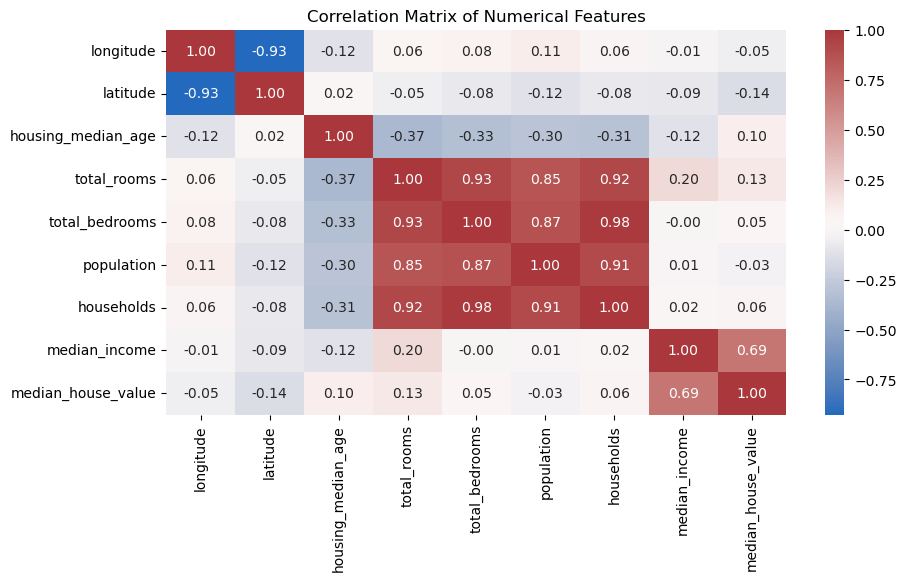

In [43]:
plt.figure(figsize=(10, 5))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="vlag",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

**Interpretation:**

The correlation heatmap shows that **`median_income` has the strongest positive correlation with `median_house_value` (0.69)**. This indicates that areas with higher median income tend to have **higher median house values**.


### 5. **Correlation of median_income with median_house_value**

<Axes: xlabel='median_income', ylabel='median_house_value'>

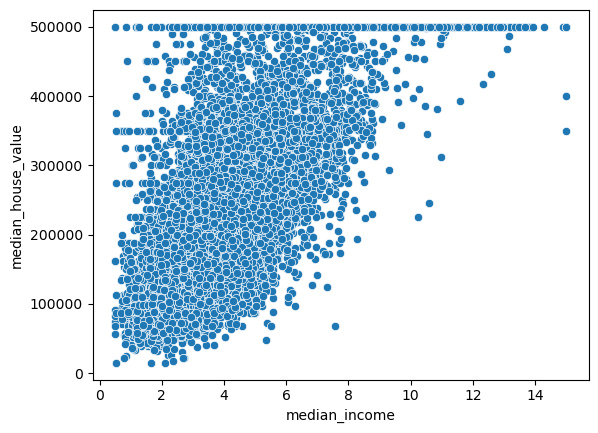

In [46]:
sns.scatterplot(data=df, x='median_income', y='median_house_value')

**Interpretation:**

There is a **positive relationship between `median_income` and `median_house_value`**. As median income increases, median house value tends to increase as well. The plot also shows an **upper price cap around $500,000**, which may affect the model's ability to predict higher property values.

### 6. **Average House Value by Ocean Proximity**

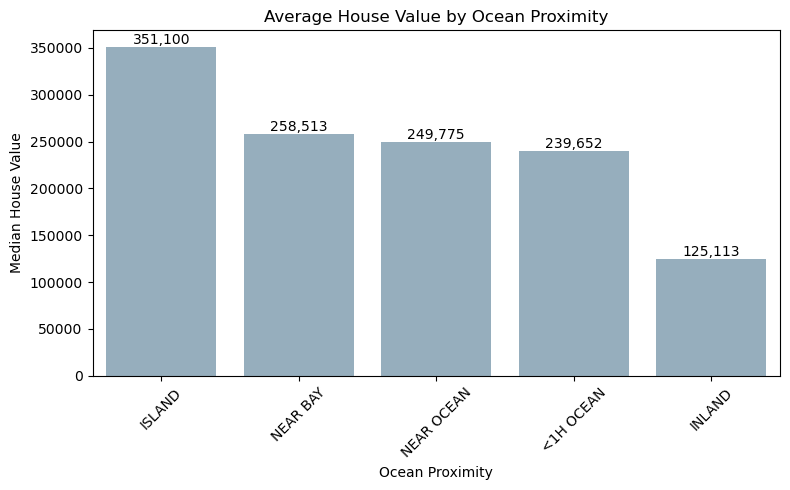

In [48]:
plt.figure(figsize=(8, 5))

df_sorted = (
    df.groupby('ocean_proximity')['median_house_value']
    .mean()
    .reset_index()
    .sort_values('median_house_value', ascending=False)
)

ax = sns.barplot(
    data=df_sorted,
    x='ocean_proximity',
    y='median_house_value',
    color='#8FAFC4'
)

ax.set_title('Average House Value by Ocean Proximity')
ax.set_ylabel('Median House Value')
ax.set_xlabel('Ocean Proximity')

plt.xticks(rotation=45)

# Annotations
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():,.0f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 5),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()

In [49]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     6369
INLAND        4576
NEAR OCEAN    1879
NEAR BAY      1622
ISLAND           2
Name: count, dtype: int64

### 7. **Relationship of Property Locations with House Price**

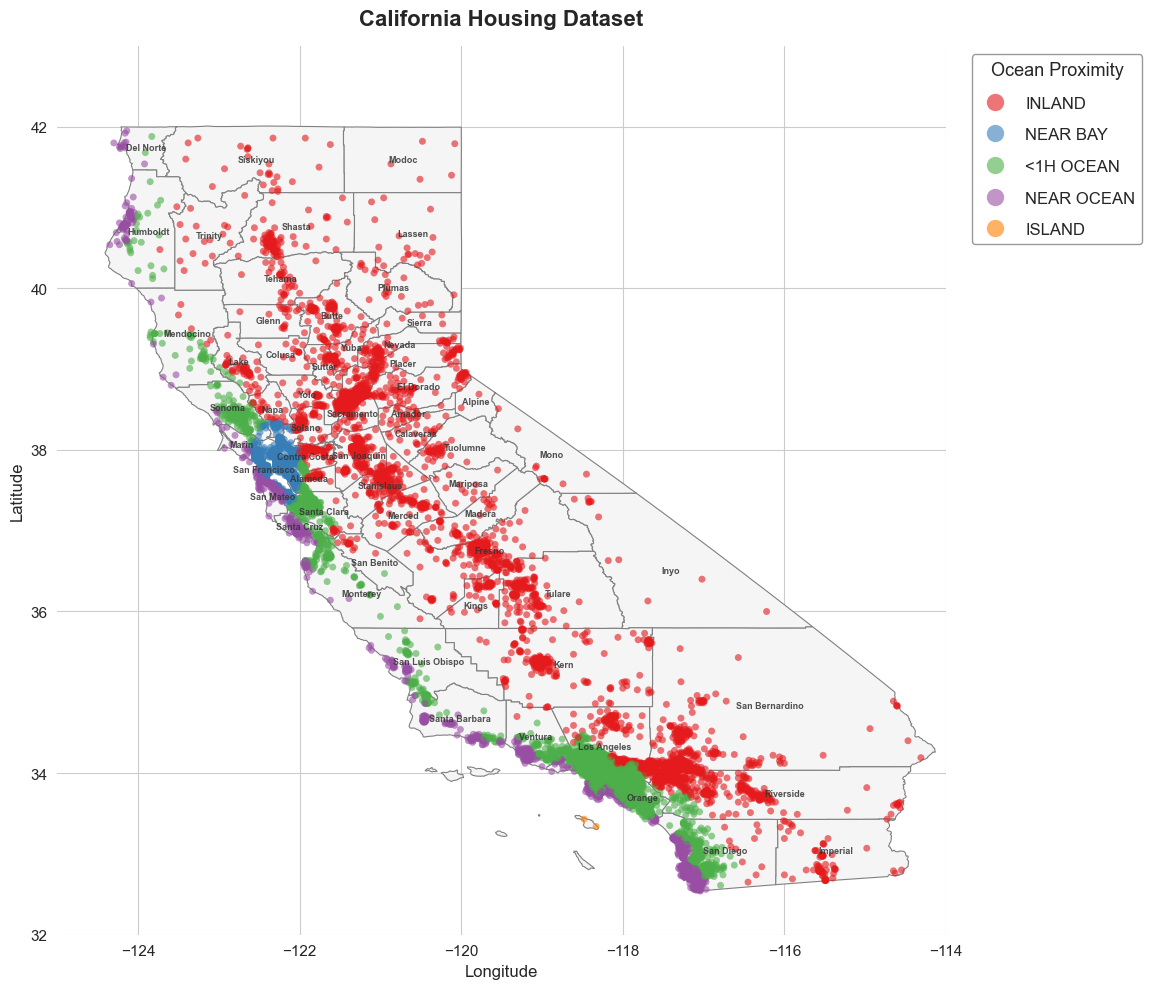

In [171]:
# Load county boundaries CA
counties_url = "https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/california-counties.geojson"
counties = gpd.read_file(counties_url)

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(12, 10))

counties.plot(ax=ax, color="#f5f5f5", edgecolor="gray", linewidth=0.8)

sns.scatterplot(
    data=df, x="longitude", y="latitude",
    hue="ocean_proximity", palette="Set1",
    alpha=0.6, s=25, edgecolor="none", ax=ax
)

# adding county name
for idx, row in counties.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        text=row["name"],
        xy=(centroid.x, centroid.y),
        fontsize=6.5,
        ha="center",
        va="center",
        color="#333333",
        alpha=0.85,
        fontweight="bold"
    )

ax.set_xlim(-125, -114)
ax.set_ylim(32, 43)
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)
ax.set_title("California Housing Dataset", fontsize=16, fontweight="bold", pad=15)
ax.set_aspect("equal")
ax.tick_params(labelsize=11)

legend = ax.legend(
    title="Ocean Proximity", bbox_to_anchor=(1.02, 1), loc="upper left",
    fontsize=12, title_fontsize=13, markerscale=2.5, labelspacing=1.0
)
legend.get_frame().set_edgecolor("gray")

sns.despine(ax=ax, left=True, bottom=True)
plt.tight_layout()
plt.show()

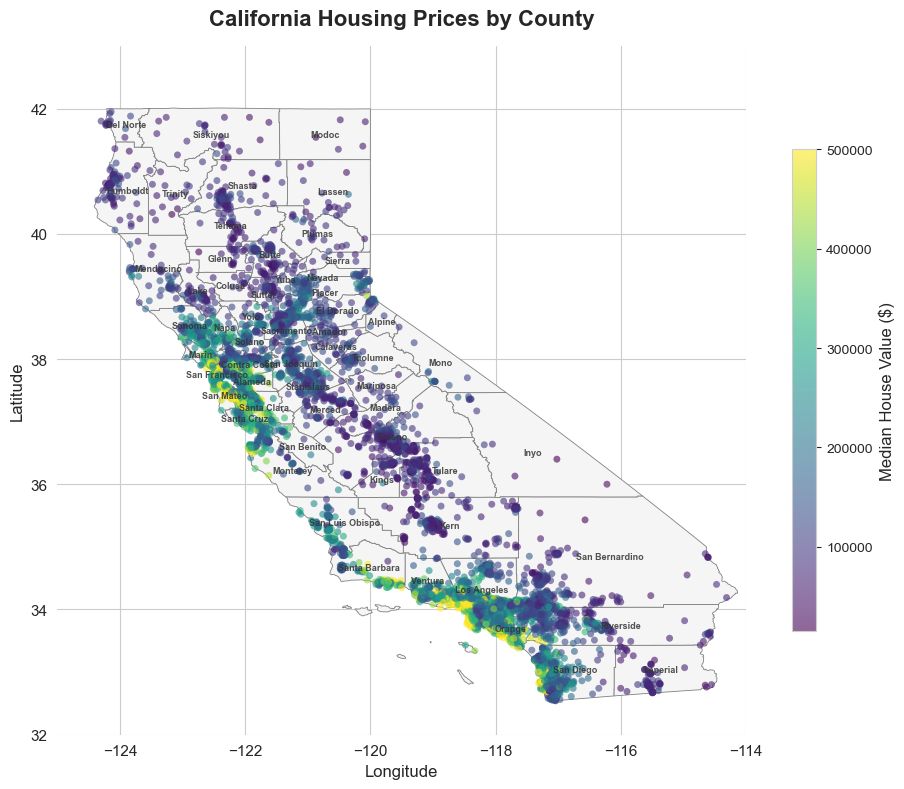

In [173]:
# Load county boundaries CA dari US Census
counties_url = "https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/california-counties.geojson"
counties = gpd.read_file(counties_url)

fig, ax = plt.subplots(figsize=(10, 8))

counties.plot(ax=ax, color="#f5f5f5", edgecolor="gray", linewidth=0.6)

scatter = ax.scatter(
    df["longitude"], df["latitude"],
    c=df["median_house_value"], cmap="viridis",
    alpha=0.6, s=25, edgecolor="none"
)

# Adding county name
for idx, row in counties.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        text=row["name"],  # sesuaikan dengan nama kolom asli (cek dari print di atas)
        xy=(centroid.x, centroid.y),
        fontsize=6.5,
        ha="center",
        va="center",
        color="#333333",
        alpha=0.85,
        fontweight="bold"
    )

ax.set_xlim(-125, -114)
ax.set_ylim(32, 43)
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)
ax.set_title("California Housing Prices by County", fontsize=16, fontweight="bold", pad=15)
ax.set_aspect("equal")
ax.tick_params(labelsize=11)

cbar = fig.colorbar(scatter, ax=ax, shrink=0.7)
cbar.set_label("Median House Value ($)", fontsize=12)

sns.despine(ax=ax, left=True, bottom=True)
plt.tight_layout()
plt.show()

**Interpretation:**

When examining the relationship between location and house prices, it can be concluded that house prices are influenced by location. The closer a property is to the coast, the higher its price tends to be.


## **Data Preprocessing**

Is conducted to ensure that the dataset is clean, consistent, and suitable for further analysis and modeling.
The main preprocessing steps include:
- Checking and handling duplicate records
- Checking and handling missing values
- Checking and handling outliers

### 1. **Check & Handling Duplicate**

In [87]:
df.duplicated().sum()

np.int64(0)

No duplicate records were found in the dataset.

### 2. **Check & Handling Missing Values**

In [88]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        137
population              0
households              0
median_income           0
ocean_proximity         0
median_house_value      0
dtype: int64

**There are 137 missing values in the total_bedrooms column**. The possible approaches for handling them are either to drop the records or impute the missing values. Since the missing values are found in the total_bedrooms column, it was **decided to inpute them using the median of the entire total_bedrooms dataset**. This approach allows us to retain the data while minimizing the impact of missing values.

In [89]:
# Changing missing values with the median
df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)

In [90]:
df.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
ocean_proximity       0
median_house_value    0
dtype: int64

After imputing the missing values, there are no remaining missing values in the dataset.


### 3. **Check & Handling Outliers**

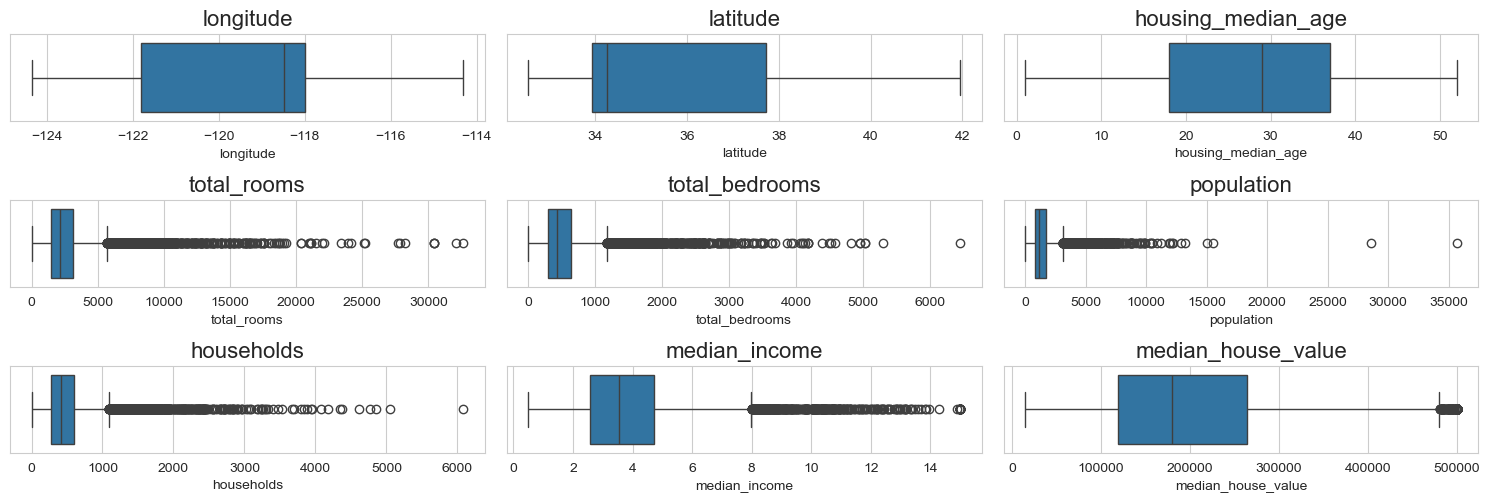

In [93]:
num_feature = df.describe().columns
plt.figure(figsize=(15, 18), facecolor='white')
plotnumber = 1
    
for feature in num_feature:
    ax = plt.subplot(11,3, plotnumber)
    sns.boxplot(x=feature, data=df)
    plt.title(feature, fontsize=16)
    plt.tight_layout()
    plotnumber = plotnumber + 1

In [94]:
# Check the number of unusually high values

print("Number of total_bedrooms > 5,000 :", (df['total_bedrooms'] > 5000).sum())
print("Number of population > 25,000   :", (df['population'] > 25000).sum())
print("Number of households > 5,000    :", (df['households'] > 5000).sum())

Number of total_bedrooms > 5,000 : 4
Number of population > 25,000   : 2
Number of households > 5,000    : 2


In [95]:
# Remove outliers

df = df[
    (df['total_bedrooms'] < 5000) &
    (df['population'] < 25000) &
    (df['households'] < 5000)
]

**Handling Outliers median_house_value**

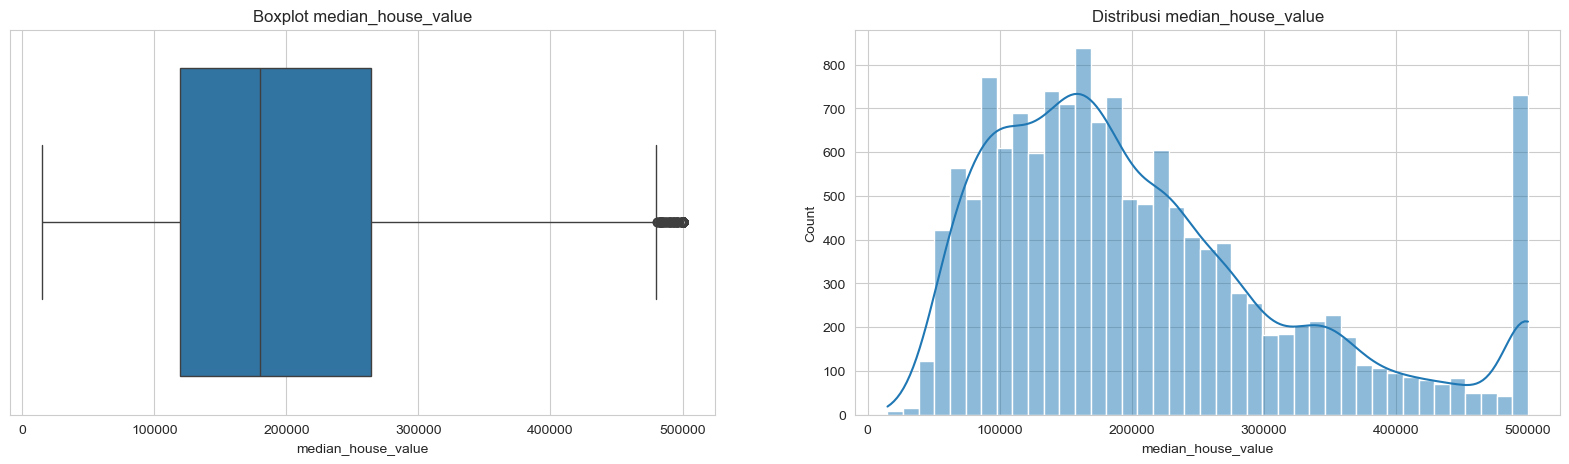

In [96]:
plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='median_house_value').set_title('Boxplot median_house_value')
plt.subplot(1, 2, 2)
sns.histplot(data=df, x='median_house_value', kde=True).set_title('Distribusi median_house_value')
plt.show()

In [97]:
display(df.groupby(by='median_house_value')['median_house_value'].count().sort_index(ascending=False).head(5))

median_house_value
500001.0    678
500000.0     18
499100.0      1
499000.0      1
498700.0      1
Name: median_house_value, dtype: int64

### Interpretation

The boxplot visualization indicates the presence of **678 records with a `median_house_value` of 500,001**, which can be considered potential outliers. These values create a noticeable spike at the upper end of the distribution, indicating that the data is not normally distributed. The value of 500,001 also appears unusual because it may represent houses priced above $500,000, while the exact prices are not specified in the dataset.

Out of **14,448 records**, 678 have a `median_house_value` of 500,001, accounting for approximately **4.69% of the dataset**. Since these observations represent a relatively small proportion of the data and may affect the model's ability to learn representative patterns, it was decided to **remove these records**.

This removal aims to reduce the potential influence of extreme values and improve the distribution of the target variable, allowing the model to better capture the patterns represented by the majority of the observations.


In [175]:
# Drop records with median_house_value of 500001
df = df.drop(df[df['median_house_value'] == 500001.0].index)

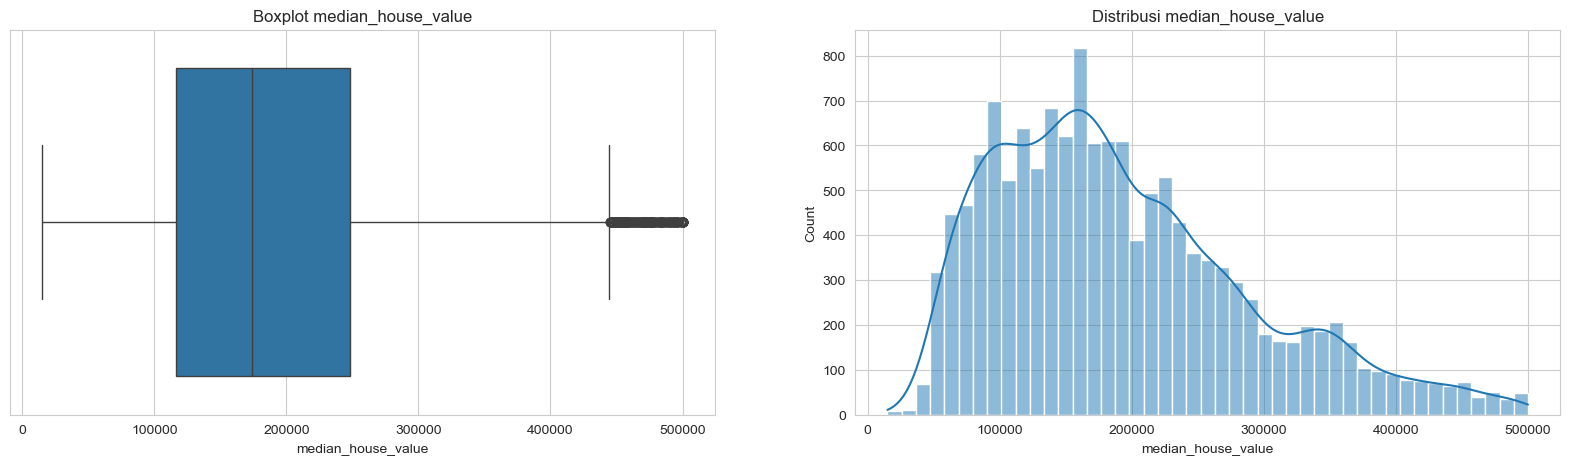

In [178]:
# Check the distribution of median_house_value after removing outliers
plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='median_house_value').set_title('Boxplot median_house_value')
plt.subplot(1, 2, 2)
sns.histplot(data=df, x='median_house_value', kde=True).set_title('Distribusi median_house_value')
plt.show()

**Handling Outliers in Categorical Variables**

In [101]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     5994
INLAND        4560
NEAR OCEAN    1732
NEAR BAY      1477
ISLAND           2
Name: count, dtype: int64

The `ocean_proximity` variable is the only categorical feature, with **ISLAND containing only 2 records (0.01%)**. Due to its extremely low representation, the ISLAND category was removed to reduce potential noise and improve model stability.


In [102]:
# Drop data "ISLAND"
df=df.drop(df[df['ocean_proximity']=='ISLAND'].index)

## **Final Data Processing**

In [183]:
# Dataset after cleaning
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-119.79,36.73,52.0,112.0,28.0,193.0,40.0,1.9750,INLAND,47500.0
1,-122.21,37.77,43.0,1017.0,328.0,836.0,277.0,2.2604,NEAR BAY,100000.0
2,-118.04,33.87,17.0,2358.0,396.0,1387.0,364.0,6.2990,<1H OCEAN,285800.0
3,-118.28,34.06,17.0,2518.0,1196.0,3051.0,1000.0,1.7199,<1H OCEAN,175000.0
4,-119.81,36.73,50.0,772.0,194.0,606.0,167.0,2.2206,INLAND,59200.0


In [181]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13770 entries, 0 to 14447
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           13770 non-null  float64
 1   latitude            13770 non-null  float64
 2   housing_median_age  13770 non-null  float64
 3   total_rooms         13770 non-null  float64
 4   total_bedrooms      13639 non-null  float64
 5   population          13770 non-null  float64
 6   households          13770 non-null  float64
 7   median_income       13770 non-null  float64
 8   ocean_proximity     13770 non-null  object 
 9   median_house_value  13770 non-null  float64
dtypes: float64(9), object(1)
memory usage: 1.2+ MB


In [182]:
df.shape

(13770, 10)

After the data cleaning and preprocessing stages, the dataset used for **machine learning modeling** consists of **13,763 rows and 10 columns**, with no remaining missing values. The dataset is now **ready for machine learning model development and evaluation**.


## **Machine Learning Modelling**

### 1. **Defining X & y**

In [108]:
X = df.drop(columns='median_house_value')
X.head(3)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-119.79,36.73,52.0,112.0,28.0,193.0,40.0,1.9750,INLAND
1,-122.21,37.77,43.0,1017.0,328.0,836.0,277.0,2.2604,NEAR BAY
2,-118.04,33.87,17.0,2358.0,396.0,1387.0,364.0,6.2990,<1H OCEAN


In [109]:
y = df['median_house_value']
y

0         47500.0
1        100000.0
2        285800.0
3        175000.0
4         59200.0
           ...   
14443    144600.0
14444    159400.0
14445    289300.0
14446    484600.0
14447     69400.0
Name: median_house_value, Length: 13763, dtype: float64

### 2. **Data Splitting**

In [112]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0
)

### 3. **ColumnTransformer**

1. Encoding
    - OneHot: ocean_proximity
3. Scaling
    - Robust: total_bedrooms, longtitude, latitude, housing_median_age, total_rooms, population, households, median_income.

In [114]:
# Define categorical and numerical features
categorical_features = ['ocean_proximity']

numerical_features = [
    'total_bedrooms',
    'longitude',
    'latitude',
    'housing_median_age',
    'total_rooms',
    'population',
    'households',
    'median_income'
]

# Create ColumnTransformer
transformer = ColumnTransformer([
    ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('scaling', RobustScaler(), numerical_features)
])

In [115]:
transformer

,transformers,"[('onehot', ...), ('scaling', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,True


### 4. **Cross Validation**

In [133]:
# Define Algo
linear = LinearRegression()
tree = DecisionTreeRegressor(random_state=0)
knn = KNeighborsRegressor()
rf = RandomForestRegressor(random_state=0)
xgb = XGBRegressor(random_state=0)

list_model = [linear, tree, knn, rf, xgb]

scorer = ["neg_root_mean_squared_error",
          "neg_mean_absolute_percentage_error",
          "neg_mean_absolute_error"]

# List Score RMSE
list_score_mean_rmse = []
list_score_std_rmse = []

# List Score MAE
list_score_mean_mae = []
list_score_std_mae = []

# List Score MAPE
list_score_mean_mape = []
list_score_std_mape = []

# Cross Validation loop
for model in list_model:
    pipe_model = Pipeline([
        ("Preprocessing", transformer),
        ("Modeling", model)])

    cv_score = cross_validate(
        estimator=pipe_model,
        X=X_train,
        y=y_train,
        cv=5,
        scoring=scorer,
        return_train_score=True)

    # RMSE
    list_score_mean_rmse.append(cv_score["test_neg_root_mean_squared_error"].mean())
    list_score_std_rmse.append(cv_score["test_neg_root_mean_squared_error"].std())

    # MAE
    list_score_mean_mae.append(cv_score["test_neg_mean_absolute_error"].mean())
    list_score_std_mae.append(cv_score["test_neg_mean_absolute_error"].std())

    # MAPE
    list_score_mean_mape.append(cv_score["test_neg_mean_absolute_percentage_error"].mean())
    list_score_std_mape.append(cv_score["test_neg_mean_absolute_percentage_error"].std())
    

In [134]:
df_cv = pd.DataFrame()
df_cv["Model"] = ['Linear Regression', 'DecisionTree Regressor', 'KNN Regressor', 'RandomForest Regressor', 'XGBoost Regressor']
df_cv["Mean RMSE"] = list_score_mean_rmse
df_cv["Std RMSE"] = list_score_std_rmse
df_cv["Mean MAE"] = list_score_mean_mae
df_cv["Std MAE"] = list_score_std_mae
df_cv["Mean MAPE"] = list_score_mean_mape
df_cv["Std MAPE"] = list_score_std_mape
df_cv

,Model,Mean RMSE,Std RMSE,Mean MAE,Std MAE,Mean MAPE,Std MAPE
0,Linear Regression,-60688.931791,587.617407,-44798.028351,657.455672,-0.272843,0.001993
1,DecisionTree Regressor,-66495.416072,1243.781807,-44699.573842,770.510995,-0.255904,0.007459
2,KNN Regressor,-57033.329612,399.678425,-39921.070209,374.505049,-0.230726,0.002998
3,RandomForest Regressor,-47231.867212,383.167168,-32211.860511,226.305411,-0.188997,0.002732
4,XGBoost Regressor,-44820.609123,426.433642,-30692.803174,188.240967,-0.179901,0.000982


**Interpretation:**

Based on the cross-validation results, XGBoost demonstrates the best overall performance, achieving the lowest mean RMSE, MAE, and MAPE compared to Random Forest. This indicates that XGBoost provides more accurate predictions on average.

Although Random Forest has a slightly lower standard deviation for RMSE, indicating more consistent performance for this metric, XGBoost shows lower standard deviations for both MAE and MAPE. Overall, XGBoost is considered the best-performing model based on its lower average errors and relatively consistent performance across the cross-validation folds.

To further validate the model's performance, a benchmarking evaluation on the test set will be conducted. This step will assess how well the selected models perform on unseen data and determine which model provides the most reliable predictions.

**Predict to Test with Random Forest & XGBoost**

In [136]:
# Benchmark the two best-performing models

models = {
    'Random Forest': RandomForestRegressor(random_state=1),
    'XGBoost': XGBRegressor(random_state=1)
}

score_rmse = []
score_mae = []
score_mape = []

# Evaluate both models on the test set
for name, model in models.items():

    pipe_model = Pipeline([
        ('preprocessing', transformer),
        ('model', model)
    ])

    pipe_model.fit(X_train, y_train)
    y_pred = pipe_model.predict(X_test)

    score_rmse.append(
        np.sqrt(mean_squared_error(y_test, y_pred))
    )

    score_mae.append(
        mean_absolute_error(y_test, y_pred)
    )

    score_mape.append(
        mean_absolute_percentage_error(y_test, y_pred)
    )

score_before_tuning = pd.DataFrame({
    'RMSE': score_rmse,
    'MAE': score_mae,
    'MAPE': score_mape
}, index=models.keys())

score_before_tuning

,RMSE,MAE,MAPE
Random Forest,45680.671083,31075.109085,0.184505
XGBoost,44682.811639,30038.588609,0.177098


Based on the benchmarking results, XGBoost outperformed Random Forest, achieving lower RMSE, MAE, and MAPE values. This indicates that XGBoost provides more accurate predictions on the unseen test data. Therefore, XGBoost was selected as the best-performing model for this project.

## 5. **Hyperparameter Tuning**

In [138]:
# Define Hyperparameters
hyperparameter = {
    'Modeling__n_estimators': list(np.arange(100, 1001, 100)),
    'Modeling__max_depth': list(np.arange(3, 22)),
    'Modeling__learning_rate': list(np.arange(1, 100) / 100),
    'Modeling__subsample': list(np.arange(2, 11) / 10),
    'Modeling__colsample_bytree': list(np.arange(1, 11) / 10),
    'Modeling__reg_alpha': list(np.logspace(-3, 1, 10))
}

# Define XGBoost Model
xgb_model = XGBRegressor(
    random_state=0
)

# Define Scoring Metrics
scorer = [
    "neg_root_mean_squared_error",
    "neg_mean_absolute_percentage_error",
    "neg_mean_absolute_error"
]

# Define Pipeline
pipe_model = Pipeline([
    ("Preprocessing", transformer),
    ("Modeling", xgb_model)
])

# Define RandomizedSearchCV
randomized_xgb = RandomizedSearchCV(
    estimator=pipe_model,
    param_distributions=hyperparameter,
    n_iter=100,
    scoring=scorer,
    refit="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=0
)

In [139]:
# Fit the model to the training data
randomized_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'Modeling__colsample_bytree': [np.float64(0.1), np.float64(0.2), ...], 'Modeling__learning_rate': [np.float64(0.01), np.float64(0.02), ...], 'Modeling__max_depth': [np.int64(3), np.int64(4), ...], 'Modeling__n_estimators': [np.int64(100), np.int64(200), ...], ...}"
,n_iter,100
,scoring,"['neg_root_mean_squared_error', 'neg_mean_absolute_percentage_error', ...]"
,n_jobs,-1
,refit,'neg_root_mean_squared_error'
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,0
,error_score,nan


In [140]:
pd.set_option('display.max_columns', None)
df_randomized_xgb = pd.DataFrame(randomized_xgb.cv_results_).sort_values(by=['rank_test_neg_root_mean_squared_error', 'rank_test_neg_mean_absolute_error', 'rank_test_neg_mean_absolute_percentage_error'])
df_randomized_xgb.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_Modeling__subsample,param_Modeling__reg_alpha,param_Modeling__n_estimators,param_Modeling__max_depth,param_Modeling__learning_rate,param_Modeling__colsample_bytree,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_percentage_error,split1_test_neg_mean_absolute_percentage_error,split2_test_neg_mean_absolute_percentage_error,split3_test_neg_mean_absolute_percentage_error,split4_test_neg_mean_absolute_percentage_error,mean_test_neg_mean_absolute_percentage_error,std_test_neg_mean_absolute_percentage_error,rank_test_neg_mean_absolute_percentage_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
72,11.852808,0.257504,0.235532,0.010314,0.9,0.002783,800,6,0.10,0.6,"{'Modeling__subsample': 0.9, 'Modeling__reg_al...",-43676.679340,-43733.239391,-43979.364457,-43268.876489,-43020.215312,-43535.674998,344.283134,1,-0.174841,-0.176941,-0.178623,-0.169739,-0.170361,-0.174101,0.003524,1,-29744.946884,-29894.556779,-30152.313665,-28516.411614,-29413.938688,-29544.433526,566.774755,1
76,10.196055,1.852043,0.166031,0.021131,0.7,0.007743,900,4,0.11,0.9,"{'Modeling__subsample': 0.7, 'Modeling__reg_al...",-43816.330852,-43956.966019,-43209.282458,-44095.147476,-43304.810902,-43676.507541,354.943539,2,-0.177168,-0.177000,-0.176106,-0.174368,-0.173163,-0.175561,0.001557,2,-29849.968822,-29858.502413,-29824.255215,-29133.289988,-29615.909502,-29656.385188,276.323438,2
20,19.548070,0.464953,0.452353,0.011167,0.8,1.291550,500,9,0.03,0.4,"{'Modeling__subsample': 0.8, 'Modeling__reg_al...",-44541.704313,-44386.194623,-45837.566578,-44772.854187,-44869.484133,-44881.560767,507.306634,3,-0.182898,-0.186288,-0.186440,-0.178084,-0.183503,-0.183443,0.003036,4,-30825.294136,-30851.309027,-31383.296071,-29737.404902,-31056.735487,-30770.807925,553.943550,4
75,23.712825,1.213410,0.296384,0.044835,1.0,0.007743,200,12,0.11,0.9,"{'Modeling__subsample': 1.0, 'Modeling__reg_al...",-44930.991859,-45679.689958,-47133.293771,-45130.699428,-45030.738293,-45581.082662,818.220601,4,-0.173471,-0.178608,-0.184482,-0.173299,-0.175458,-0.177064,0.004173,3,-30121.601541,-30697.381714,-31563.618873,-29649.067068,-30552.481058,-30516.830051,638.569480,3
37,45.091151,0.713771,0.481782,0.021687,0.6,0.001000,100,20,0.03,0.9,"{'Modeling__subsample': 0.6, 'Modeling__reg_al...",-46092.609085,-45954.829951,-46743.571092,-46096.647649,-45248.107607,-46027.153077,476.342573,5,-0.188174,-0.190505,-0.194081,-0.188216,-0.188087,-0.189813,0.002320,5,-31436.561588,-31496.515928,-32047.826128,-30954.594092,-31452.786698,-31477.656887,346.799845,5


In [141]:
randomized_xgb.best_estimator_

,steps,"[('Preprocessing', ...), ('Modeling', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehot', ...), ('scaling', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [142]:
# Check the best score and hyperparameters

print('XGBoost Model')
print('Best RMSE:', -randomized_xgb.best_score_)
print('Best Parameters:', randomized_xgb.best_params_)

XGBoost Model
Best RMSE: 43535.674997840506
Best Parameters: {'Modeling__subsample': np.float64(0.9), 'Modeling__reg_alpha': np.float64(0.0027825594022071257), 'Modeling__n_estimators': np.int64(800), 'Modeling__max_depth': np.int64(6), 'Modeling__learning_rate': np.float64(0.1), 'Modeling__colsample_bytree': np.float64(0.6)}


### 6. **Predict to Test Set with Tuned Model**

In [143]:
# Get the best XGBoost model from hyperparameter tuning
xgb_tuning = randomized_xgb.best_estimator_

# Fit the tuned model on the training data
xgb_tuning.fit(X_train, y_train)

# Predict on the test set
y_pred_xgb_tuning = xgb_tuning.predict(X_test)

# Calculate evaluation metrics
rmse_xgb_tuning = np.sqrt(
    mean_squared_error(y_test, y_pred_xgb_tuning)
)

mae_xgb_tuning = mean_absolute_error(
    y_test,
    y_pred_xgb_tuning
)

mape_xgb_tuning = mean_absolute_percentage_error(
    y_test,
    y_pred_xgb_tuning
)

# Store the results
score_after_tuning = pd.DataFrame({
    'RMSE': [rmse_xgb_tuning],
    'MAE': [mae_xgb_tuning],
    'MAPE': [mape_xgb_tuning]
}, index=['XGBoost'])

score_after_tuning

,RMSE,MAE,MAPE
XGBoost,43072.63191,28961.859084,0.170025


**Performance Comparison After Tuning**

In [146]:
# Before
print('XGBoost Performance Before Tuning')
display(pd.DataFrame(score_before_tuning.iloc[1]).T)

# After
print('XGBoost Performance After Tuning')
display(score_after_tuning)

XGBoost Performance Before Tuning


,RMSE,MAE,MAPE
XGBoost,44682.811639,30038.588609,0.177098


XGBoost Performance After Tuning


,RMSE,MAE,MAPE
XGBoost,43072.63191,28961.859084,0.170025


**Interpretation**

Based on the performance comparison, **XGBoost shows improved predictive performance after hyperparameter tuning**, with lower error values across all three evaluation metrics:

* **RMSE** decreased from **44,682.81 to 43,072.63**, an improvement of approximately **1,610.18 (3.60%)**.
* **MAE** decreased from **30,038.59 to 28,961.86**, an improvement of approximately **1,076.73 (3.58%)**.
* **MAPE** decreased from **17.71% to 17.00%**, indicating a lower average percentage error.

Overall, the results indicate that **hyperparameter tuning successfully improved the XGBoost model's predictive accuracy on the test set**. Therefore, the tuned XGBoost model was selected as the **final model** for this project.


## **Model Visualization**

### 1. **Actual Price vs Prediction Price**

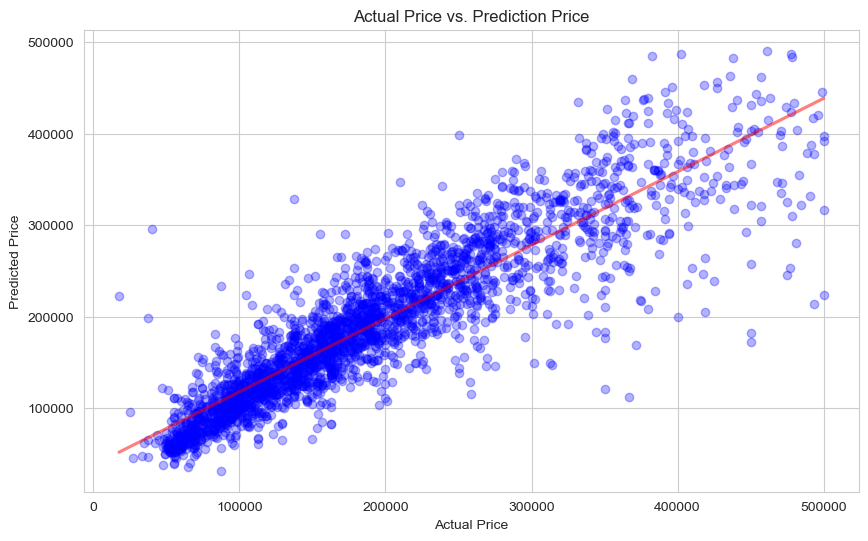

In [192]:
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred_xgb_tuning, ci=None, scatter_kws = {'color': 'blue', 'alpha': 0.3}, line_kws = {'color': 'red', 'alpha': 0.5}).set(title='Actual Price vs. Prediction Price',
            xlabel='Actual Price',
            ylabel='Predicted Price')

plt.show()

In [148]:
df_compare_harga = pd.DataFrame({'Actual Price': y_test, 'Prediction Price': y_pred_xgb_tuning})
df_compare_harga['Prediction Price'] = df_compare_harga['Prediction Price'].apply(lambda x: round(x, 1))
df_compare_harga

,Actual Price,Prediction Price
7841,169300.0,173838.5
9676,110200.0,143347.1
13346,193100.0,196023.1
6714,264300.0,279146.3
9999,124900.0,115228.3
...,...,...
10312,285000.0,300323.9
13486,110600.0,115961.8
2795,386400.0,359056.0
1982,206300.0,227792.5


**Interpretation**:

Based on the **Actual vs. Predicted Price** plot, the XGBoost model is able to predict house prices with relatively good accuracy, as indicated by the data points generally following the regression line. Most predictions are close to the line, suggesting relatively small prediction errors, although some outliers can be observed at higher house prices.

The model appears to perform better when predicting houses within the lower price range and tends to have more difficulty predicting very high house prices. This indicates a limitation of the model and suggests that further improvements could be achieved through additional model tuning or by incorporating more relevant features to improve predictions for high-priced properties.


### 2. **Residual Plot**

[Text(0.5, 0, 'median_house_value'),
 Text(0, 0.5, 'residual'),
 Text(0.5, 1.0, 'Residual value')]

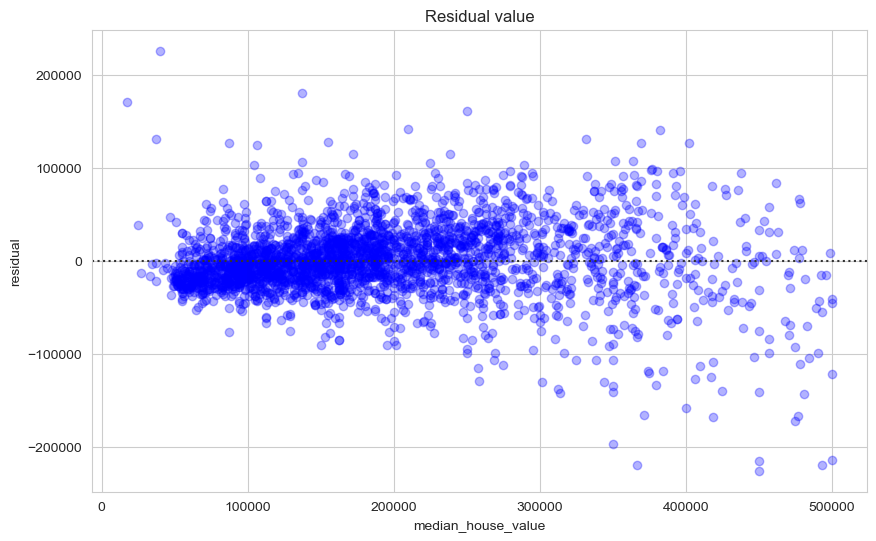

In [150]:
plt.figure(figsize=(10, 6))
sns.residplot(x=y_test, y=y_pred_xgb_tuning, scatter_kws = {'color': 'blue', 'alpha': 0.3}, line_kws = {'color': 'red', 'alpha': 0.5}).set(xlabel='median_house_value', ylabel='residual',title = 'Residual value')

**Interpretation**:

- Most residuals are distributed around zero, indicating that the model generally provides reasonably accurate predictions across the dataset.
- The residual spread becomes wider as house prices increase, suggesting that the model's predictions are less consistent for higher-priced properties.
- No clear systematic pattern or trend is observed in the residuals, which suggests that the model does not show a strong systematic bias across the target range.
- However, the increasing residual variance at higher house prices indicates heteroscedasticity, meaning the prediction errors become larger as the house price increases.

## **Feature Importance**

In [152]:
pd.Series(xgb_tuning['Modeling'].feature_importances_, transformer.get_feature_names_out()).sort_values(ascending = False)

onehot__ocean_proximity_INLAND        0.442612
scaling__median_income                0.174135
onehot__ocean_proximity_NEAR OCEAN    0.070542
scaling__longitude                    0.058173
onehot__ocean_proximity_<1H OCEAN     0.056846
onehot__ocean_proximity_NEAR BAY      0.055646
scaling__latitude                     0.044981
scaling__housing_median_age           0.026435
scaling__population                   0.020630
scaling__total_rooms                  0.018332
scaling__households                   0.018195
scaling__total_bedrooms               0.013475
dtype: float32

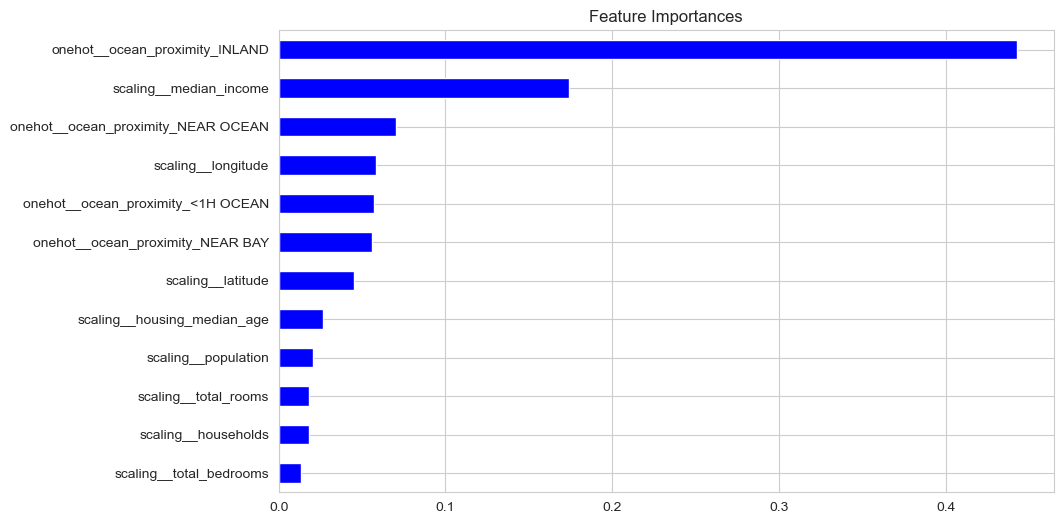

In [155]:
# Plot feature importances
plt.figure(figsize=(10, 6))
feature_importance = pd.Series(xgb_tuning['Modeling'].feature_importances_, transformer.get_feature_names_out()).sort_values(ascending=True)
feature_importance.plot(kind='barh', title='Feature Importances', color='blue')
plt.show()

**Interpretation**:

Based on the feature importance analysis, **ocean_proximity_INLAND is the most influential feature in predicting house prices**, with an importance score of 0.4426. The second most important feature is median_income, with an importance score of 0.1741.

Other relatively important features include ocean_proximity_NEAR OCEAN (0.0705), longitude (0.0582), and ocean_proximity_<1H OCEAN (0.0568). These results indicate that location-related features and median income play a major role in the XGBoost model's predictions of house prices.

## **Conclusion & Recommendation**

In [158]:
score_after_tuning

,RMSE,MAE,MAPE
XGBoost,43072.63191,28961.859084,0.170025


### **1. Conclusion**

1. **Model:** Based on the cross-validation and benchmarking results between XGBoost and Random Forest, XGBoost was selected as the best-performing model, achieving the lowest RMSE, MAE, and MAPE. This indicates that XGBoost provides the most accurate predictions among the evaluated models.
2. **Evaluation Metrics**: After hyperparameter tuning and evaluation on the test set, the final XGBoost model achieved:
     - RMSE: 43,072.63
     - MAE: 28,961.86
     - MAPE: 17.00%

    A MAPE of approximately 17% indicates that the model's predictions have an average absolute percentage error of around 17% compared with the    actual house prices.
3. **Actual vs. Predicted**: The visualization shows that the model performs reasonably well, particularly for houses in the lower-to-middle price range. However, prediction errors become larger for very high-priced properties, indicating room for further improvement in this segment.
4. **Feature Importance**: ocean_proximity_INLAND is the most influential feature in the model, with an importance score of 0.4426 (44.26%), followed by median_income (0.1741). This indicates that location-related information and median income play important roles in the model's house price predictions.

### **2. Recommendation**

**A. For the Machine Learning Model:**

1. **Optimize Hyperparameters with GridSearch.** To achieve more optimal model performance, hyperparameter tuning can be done using GridSearch. This method systematically tries every combination of parameters to find the best configuration. However, this process can be fairly time-consuming since it must evaluate all possible combinations.
2. **Perform Iterative Feature Selection** to select the subset of features that are genuinely relevant and remove those with little influence, making the model simpler, faster, and still capable of producing accurate predictions.
3. **Evaluate the Model Periodically.** Given how dynamic the property market is, Homeniq should retrain and re-evaluate model performance at least every 6 months, or whenever a major market trend shift occurs.
4. **Limit the Model's Prediction Scope to Properties Under 500,000 USD**. Since records with a `median_house_value` above 500,000 USD were removed during preprocessing (capped values), the final model was never trained on high-value properties. Homeniq should explicitly state this as a deployment guardrail — for properties above $500,000, valuations should still rely on manual appraisal, or a separate model trained on uncapped data should be developed.


**B. For the Dataset:**

1. **Update the Data.** Since the dataset used reflects data from 1990, newer data that better reflects current property prices should be collected, so that the resulting price predictions are more accurate and relevant to present market conditions, given the effect of inflation over the years.
2. **Add Features** that could significantly influence property prices, such as land area, building size, distance to public facilities, and so on, to improve prediction accuracy.
3. **Collect Uncapped Price Data**, particularly for the segment above 500,000 USD, so that future models can be trained to cover the full range of California's housing market rather than only the low-to-mid segment.

## **Save Machine Learning Model**

In [193]:
randomized_xgb.best_estimator_

,steps,"[('Preprocessing', ...), ('Modeling', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehot', ...), ('scaling', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [208]:
# Define Final Model
final_model = randomized_xgb.best_estimator_

# Save
pickle.dump(final_model, open('XGBoostModel_CaliforniaHouse.sav', 'wb'))

In [209]:
# Load Model
loaded_model = pickle.load(open('XGBoostModel_CaliforniaHouse.sav', 'rb'))

## **Testing machine learning models**

In [210]:
# Pick one sample from the test set to simulate a prediction
sample_idx = 7
X_test.iloc[[sample_idx]]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
8170,-118.37,34.19,41.0,2924.0,867.0,2751.0,836.0,2.1,<1H OCEAN


In [211]:
# Actual price for the selected sample
actual_price = y_test.iloc[sample_idx]
actual_price

np.float64(171600.0)

In [212]:
# Predict the price using the trained model
predicted_price = loaded_model.predict(X_test.iloc[[sample_idx]])
predicted_price

array([171661.75], dtype=float32)

In [213]:
# Compare actual vs predicted, including the difference
diff = predicted_price[0] - actual_price
print(f"Actual    : {actual_price:,.0f}")
print(f"Predicted : {predicted_price[0]:,.0f}")
print(f"Difference: {diff:,.0f} ({diff/actual_price*100:.2f}%)")

Actual    : 171,600
Predicted : 171,662
Difference: 62 (0.04%)


**Interpretation:**

This simulation shows the model predicted a price of **171,662 USD** against an actual value of **171,600 USD** with a difference of just **62 USD (0.04%)**, demonstrating that the tuned XGBoost model is capable of producing highly accurate, business-usable predictions at the individual property level.